In [1]:
import numpy as np
import torch
import einops
import os
import pandas as pd
from coref import COREF_ROOT
from coref.utils import cache
from functools import partial

from coref.datasets.common import Name, Attr, Statement

from coref.datasets.api import load_vocab, generate_prompts, generate_tokenized_prompts
from coref.models import fetch_model

import matplotlib.pyplot as plt
import seaborn as sns
import transformer_lens.utils as utils

import coref.representations as rep


import coref.data_collection as dc

importing dataset common


In [2]:

def reduce_logit_mean(all_logits):
    '''
    all_logits: [..., name, batch, answer]
    '''
    return all_logits.mean(dim=-2)

def reduce_acc(all_logits, intended_answers):
    '''
    all_logits: [..., name, batch, answer]
    intended_answers: [..., name]
    '''
    
    intended_answers = torch.tensor(intended_answers)
    return (all_logits.argmax(dim=-1) == intended_answers[..., None]).float().mean(dim=-1)
    
def reduce_mean_correct_logit(all_logits, intended_answers, ignore_null=False):
    # intended_answers: [..., name]
    if ignore_null:
        all_logits = all_logits[..., :-1, :, :]
    mat = reduce_logit_mean(all_logits) # [..., name, answer]
    intended_answers = torch.tensor(intended_answers)[..., None]
    return torch.gather(mat, dim=-1, index=intended_answers)[..., 0]

def reduce_balanced_acc(all_logits, intended_answers, offsets=None, ignore_null=False):
    if ignore_null:
        all_logits = all_logits[..., :-1, :, :]
    if offsets is None:
        # median is taken over name and batch
        median = torch.flatten(all_logits, start_dim=-3, end_dim=-2).quantile(dim=-2, q=0.5) # we've lost both dimensions
        offsets = median[..., None, None, :] # restore dimensions
    rebalanced_logits = all_logits - offsets
    return reduce_acc(rebalanced_logits, intended_answers)

def reduce_distractor_acc(tensor, intended_answers):
    '''
    tensor: [..., name, batch, attr]
    '''
    baseline = tensor[..., -1:, :, :].quantile(dim=-2, q=0.5, keepdim=True)
    mat = tensor[..., :-1, :, :]
    return reduce_balanced_acc(mat, intended_answers=intended_answers, offsets=baseline)



def heatmap(ax, tensor):
    sns.heatmap(
        utils.to_numpy(tensor), ax=ax, annot=True, fmt=".2f", square=True, vmin=-5, vmax=0, cbar=False, cmap=sns.color_palette("dark:#5A9", as_cmap=True))

from matplotlib.patches import Rectangle
def plot_factorization(results, highlight=None):
    tens = reduce_logit_mean(results)
    num_row, num_col = 2, 2
    fig, axs = plt.subplots(num_row, num_col, figsize=(4.5, 4.5))
    plot_titles = {
        (0, 0): "None",
        (0, 1): "Attribute",
        (1, 0): "Entity",
        (1, 1): "Both"
    }
    coords = [(r, c) for r in range(num_row) for c in range(num_col)]
    highlight_squares = {
        (r, c): highlight[i] if highlight is not None else []
        for i, (r,c) in enumerate(coords)
    }
    for r in range(num_row):
        for c in range(num_col):
            ax = axs[r, c]
            heatmap(ax, tens[r, c, :, :])
            if (r, c) == (0, 0):
                ax.set_title('None')
            if (r, c) == (0, 1):
                ax.set_title('Attribute')
            if (r, c) == (1, 0):
                ax.set_title('Entity')
            if (r, c) == (1, 1):
                ax.set_title('Both')
            for sqr, sqc in highlight_squares[(r, c)]:
                ax.add_patch(Rectangle((sqc, sqr), 1, 1, fill=False, edgecolor='crimson', lw=1.5, clip_on=False))
            # ax.set_title(f"$x_E={r}$, $x_A={c}$")
            if r == 1:
                ax.set_xticklabels(['$A_0$', '$A_1$', "$A_0'$", "$A_1'$"])
            else:
                ax.set_xticklabels([])
            if c == 0:
                ax.set_yticklabels(['$E_0$', '$E_1$', "$E_0'$", "$E_1'$"]) 
            else:
                ax.set_yticklabels([])
            if c == 0:
                ax.set_ylabel("Query name")
            if r == 1:
                ax.set_xlabel("Attributes")
    fig.tight_layout()
    return fig

## Config

In [3]:
time_tag = 'results'

# pythia 70m

In [4]:
model_tag="eleutheraipythia-70m"
data_cache = partial(cache, prefixes=[os.path.join(COREF_ROOT, 'cache'), 'paper_data', model_tag, time_tag], force_compute=False)

## Factorizability

In [5]:
highlighted_squares = [
    [
        [(0, 0), (1, 1)],
        [(0, 2), (1, 1)],
        [(2, 0), (1, 1)],
        [(2, 2), (1, 1)]
    ],
    [
        [(0, 0), (1, 1)],
        [(0, 0), (1, 3)],
        [(0, 0), (3, 1)],
        [(0, 0), (3, 3)]
    ]
]

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/eleutheraipythia-70m/results/factorizability_capitals_side_0_2_1.pt


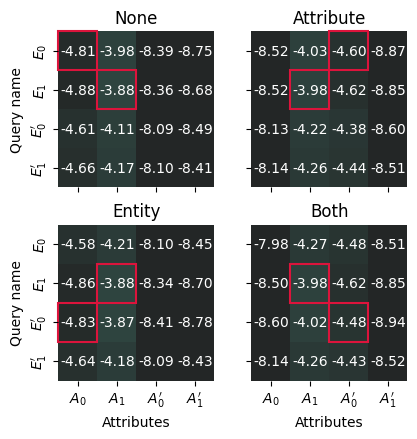

In [6]:
vocab_tag = 'CAPITALS'
country_width=1
entity_width=2
num_entities=2
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{0}_{entity_width}_{country_width}', lambda:None)
plot_factorization(factorization_results, highlight=highlighted_squares[0])
plt.savefig('figures/factorization_side0.pdf',bbox_inches='tight')

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/eleutheraipythia-70m/results/factorizability_capitals_side_1_2_1.pt


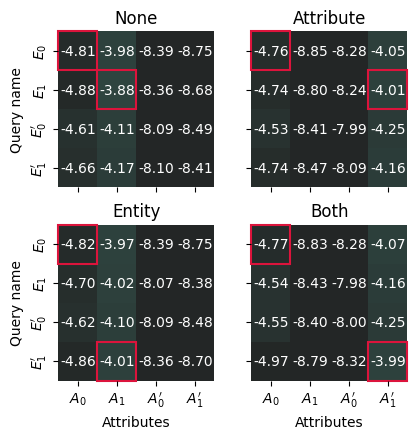

In [7]:
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{1}_{entity_width}_{country_width}', lambda:None)
fig = plot_factorization(factorization_results, highlight=highlighted_squares[1])
plt.savefig('figures/factorization_side1.pdf',bbox_inches='tight')

# Pythia 1B

In [8]:
model_tag="eleutheraipythia-1b"
data_cache = partial(cache, prefixes=[os.path.join(COREF_ROOT, 'cache'), 'paper_data', model_tag, time_tag], force_compute=False)

## Factorizability

In [9]:
highlighted_squares = [
    [
        [(0, 0), (1, 1)],
        [(0, 2), (1, 1)],
        [(2, 0), (1, 1)],
        [(2, 2), (1, 1)]
    ],
    [
        [(0, 0), (1, 1)],
        [(0, 0), (1, 3)],
        [(0, 0), (3, 1)],
        [(0, 0), (3, 3)]
    ]
]

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/eleutheraipythia-1b/results/factorizability_capitals_side_0_2_1.pt


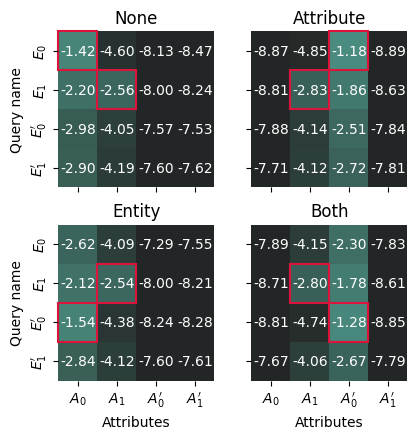

In [10]:
vocab_tag = 'CAPITALS'
country_width=1
entity_width=2
num_entities=2
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{0}_{entity_width}_{country_width}', lambda:None)
plot_factorization(factorization_results, highlight=highlighted_squares[0])
plt.savefig('figures/factorization_side0.pdf',bbox_inches='tight')

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/eleutheraipythia-1b/results/factorizability_capitals_side_1_2_1.pt


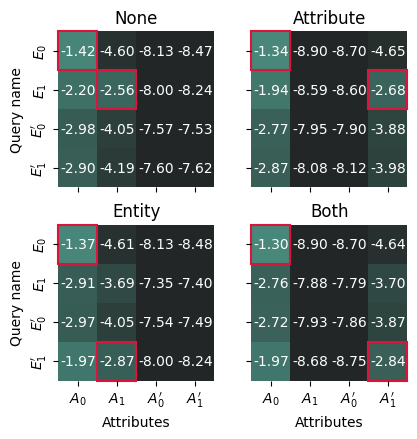

In [11]:
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{1}_{entity_width}_{country_width}', lambda:None)
fig = plot_factorization(factorization_results, highlight=highlighted_squares[1])
plt.savefig('figures/factorization_side1.pdf',bbox_inches='tight')

# Llama 7b

In [13]:
model_tag="llama-7b-hf"
data_cache = partial(cache, prefixes=[os.path.join(COREF_ROOT, 'cache'), 'paper_data', model_tag, time_tag], force_compute=False)

## Factorizability

In [14]:
highlighted_squares = [
    [
        [(0, 0), (1, 1)],
        [(0, 2), (1, 1)],
        [(2, 0), (1, 1)],
        [(2, 2), (1, 1)]
    ],
    [
        [(0, 0), (1, 1)],
        [(0, 0), (1, 3)],
        [(0, 0), (3, 1)],
        [(0, 0), (3, 3)]
    ]
]

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/llama-7b-hf/results/factorizability_capitals_side_0_2_1.pt


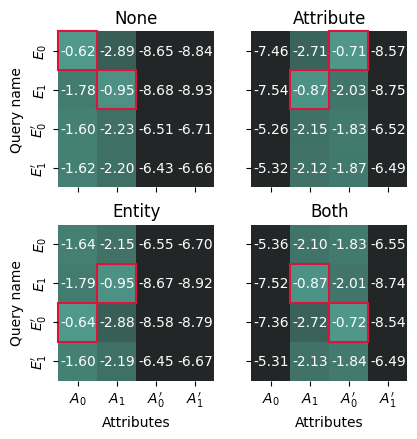

In [15]:
vocab_tag = 'CAPITALS'
country_width=1
entity_width=2
num_entities=2
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{0}_{entity_width}_{country_width}', lambda:None)
plot_factorization(factorization_results, highlight=highlighted_squares[0])
plt.savefig('figures/factorization_side0.pdf',bbox_inches='tight')

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/llama-7b-hf/results/factorizability_capitals_side_1_2_1.pt


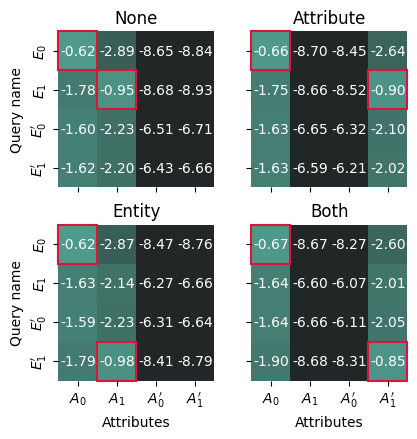

In [16]:
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{1}_{entity_width}_{country_width}', lambda:None)
fig = plot_factorization(factorization_results, highlight=highlighted_squares[1])
plt.savefig('figures/factorization_side1.pdf',bbox_inches='tight')

# Dataset en Español

In [17]:
time_tag = 'results_es'

## Pythia 70M

In [18]:
model_tag="eleutheraipythia-70m"
data_cache = partial(cache, prefixes=[os.path.join(COREF_ROOT, 'cache'), 'paper_data', model_tag, time_tag], force_compute=False)

## Factorizability

In [19]:
highlighted_squares = [
    [
        [(0, 0), (1, 1)],
        [(0, 2), (1, 1)],
        [(2, 0), (1, 1)],
        [(2, 2), (1, 1)]
    ],
    [
        [(0, 0), (1, 1)],
        [(0, 0), (1, 3)],
        [(0, 0), (3, 1)],
        [(0, 0), (3, 3)]
    ]
]

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/eleutheraipythia-70m/results_es/factorizability_capitals_es_side_0_2_1.pt


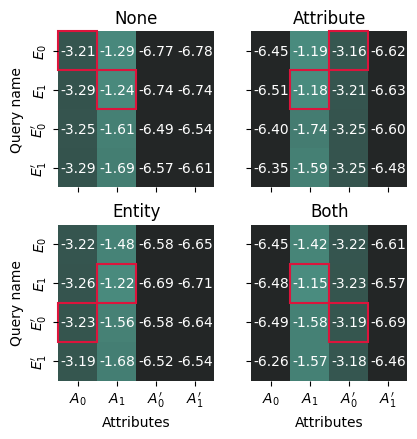

In [21]:
vocab_tag = 'CAPITALS_ES'
country_width=1
entity_width=2
num_entities=2
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{0}_{entity_width}_{country_width}', lambda:None)
plot_factorization(factorization_results, highlight=highlighted_squares[0])
plt.savefig('figures/factorization_side0.pdf',bbox_inches='tight')

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/eleutheraipythia-70m/results_es/factorizability_capitals_es_side_1_2_1.pt


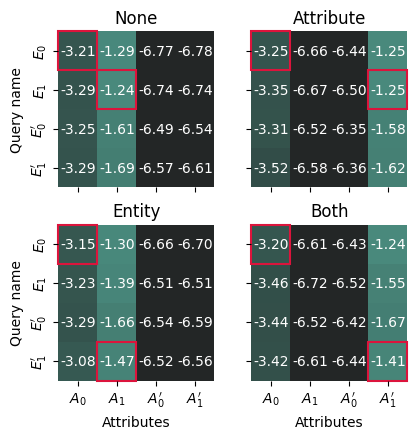

In [22]:
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{1}_{entity_width}_{country_width}', lambda:None)
fig = plot_factorization(factorization_results, highlight=highlighted_squares[1])
plt.savefig('figures/factorization_side1.pdf',bbox_inches='tight')

# Pythia 1B

In [23]:
model_tag="eleutheraipythia-1b"
data_cache = partial(cache, prefixes=[os.path.join(COREF_ROOT, 'cache'), 'paper_data', model_tag, time_tag], force_compute=False)

## Factorizability

In [24]:
highlighted_squares = [
    [
        [(0, 0), (1, 1)],
        [(0, 2), (1, 1)],
        [(2, 0), (1, 1)],
        [(2, 2), (1, 1)]
    ],
    [
        [(0, 0), (1, 1)],
        [(0, 0), (1, 3)],
        [(0, 0), (3, 1)],
        [(0, 0), (3, 3)]
    ]
]

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/eleutheraipythia-1b/results_es/factorizability_capitals_es_side_0_2_1.pt


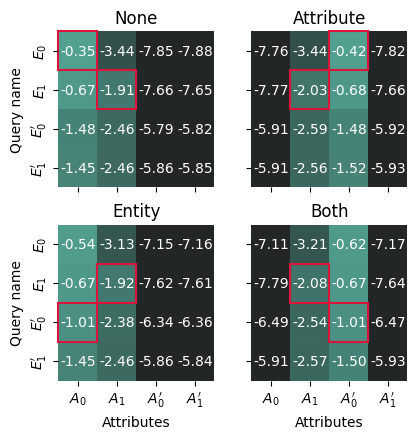

In [26]:
vocab_tag = 'CAPITALS_ES'
country_width=1
entity_width=2
num_entities=2
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{0}_{entity_width}_{country_width}', lambda:None)
plot_factorization(factorization_results, highlight=highlighted_squares[0])
plt.savefig('figures/factorization_side0.pdf',bbox_inches='tight')

using cached /Users/diegofpdt/Universidad/Semestre 12/IA Generativa/Proyecto/binding-iclr/cache/paper_data/eleutheraipythia-1b/results_es/factorizability_capitals_es_side_1_2_1.pt


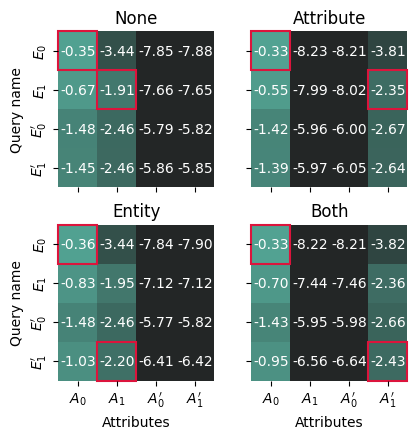

In [27]:
factorization_results = data_cache(f'factorizability_{vocab_tag}_side_{1}_{entity_width}_{country_width}', lambda:None)
fig = plot_factorization(factorization_results, highlight=highlighted_squares[1])
plt.savefig('figures/factorization_side1.pdf',bbox_inches='tight')